<a href="https://colab.research.google.com/github/asetya/BigData/blob/master/Heuristic_TSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup Problem

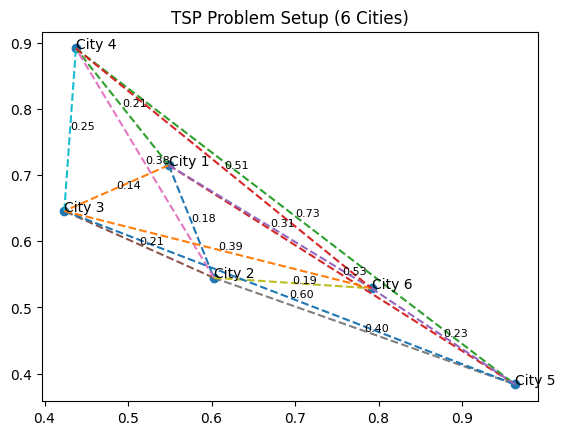

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Fix seed for reproducibility
np.random.seed(0)

# Generate 6 cities
cities = np.random.rand(6, 2)

# Naming cities
city_names = [f"City {i+1}" for i in range(len(cities))]

# Distance function
def distance(a, b):
    return np.linalg.norm(a - b)

# Distance matrix
dist_matrix = np.zeros((6, 6))
for i in range(6):
    for j in range(6):
        dist_matrix[i][j] = distance(cities[i], cities[j])

# =========================
# Plot cities + distances
# =========================
fig, ax = plt.subplots()

# Plot cities
ax.scatter(cities[:, 0], cities[:, 1])

# Label cities
for i, (x, y) in enumerate(cities):
    ax.text(x, y, f"{city_names[i]}", fontsize=10)

# Draw all connections + distances
for i in range(6):
    for j in range(i+1, 6):
        x_vals = [cities[i][0], cities[j][0]]
        y_vals = [cities[i][1], cities[j][1]]
        ax.plot(x_vals, y_vals, linestyle='dashed')

        mid_x = (cities[i][0] + cities[j][0]) / 2
        mid_y = (cities[i][1] + cities[j][1]) / 2

        ax.text(mid_x, mid_y, f"{dist_matrix[i][j]:.2f}", fontsize=8)

ax.set_title("TSP Problem Setup (6 Cities)")
plt.show()

Distance Matrix

In [35]:
import pandas as pd
import numpy as np # Ensure numpy is imported for numerical operations

# Calculate the distance matrix
num_cities = len(cities)
dist_matrix = np.zeros((num_cities, num_cities))
for i in range(num_cities):
    for j in range(num_cities):
        dist_matrix[i, j] = distance(cities[i], cities[j])

# Generate city names based on the number of cities
city_names = [f"City {i+1}" for i in range(num_cities)]

df = pd.DataFrame(dist_matrix, index=city_names, columns=city_names)
df

,City 1,City 2,City 3,City 4,City 5,City 6
City 1,0.000000,0.178647,0.143061,0.208694,0.531184,0.306124
City 2,0.178647,0.000000,0.205629,0.384208,0.395363,0.189637
City 3,0.143061,0.205629,0.000000,0.246273,0.600408,0.386218
City 4,0.208694,0.384208,0.246273,0.000000,0.731544,0.507044
City 5,0.531184,0.395363,0.600408,0.731544,0.000000,0.225209
City 6,0.306124,0.189637,0.386218,0.507044,0.225209,0.000000


Naming

In [36]:
def plot_cities_with_labels(ax, cities):
    ax.scatter(cities[:, 0], cities[:, 1])

    for i, (x, y) in enumerate(cities):
        ax.text(x, y, f"City {i+1}", fontsize=10)

AStar

# AStar

In [37]:
best_routes = []

all_routes = list(itertools.permutations(range(len(cities))))

for route in all_routes:
    best_routes.append((route, total_distance(route)))

best_routes = sorted(best_routes, key=lambda x: x[1])

# ambil top 30 untuk animasi
routes_for_anim = best_routes[:30]

**Display**

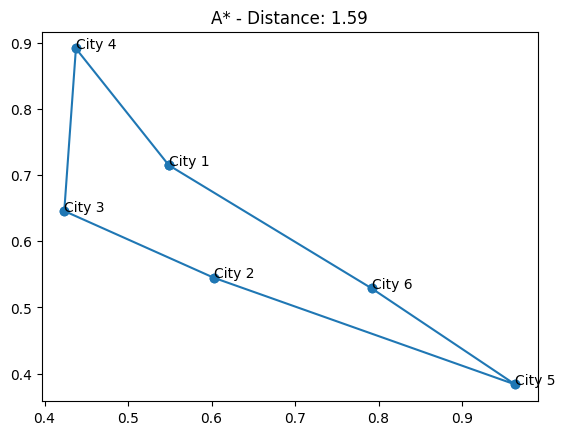

In [38]:
fig, ax = plt.subplots()

def update_astar(frame):
    ax.clear()

    route, dist = routes_for_anim[frame]

    # plot cities + labels
    plot_cities_with_labels(ax, cities)

    # draw route
    pts = cities[list(route) + [route[0]]]
    ax.plot(pts[:,0], pts[:,1], marker='o')

    ax.set_title(f"A* - Distance: {dist:.2f}")

ani = FuncAnimation(fig, update_astar, frames=len(routes_for_anim), interval=500)
HTML(ani.to_jshtml())

#HILL CLIMBING

In [43]:
import random

def random_route(n):
    route = list(range(n))
    random.shuffle(route)
    return route

def get_neighbors(route):
    neighbors = []
    n = len(route)

    # swap-based neighbors
    for i in range(n):
        for j in range(i+1, n):
            new_route = route[:]
            new_route[i], new_route[j] = new_route[j], new_route[i]
            neighbors.append(new_route)

    return neighbors

def hill_climbing(cities, max_iter=100):
    current = random_route(len(cities))
    current_cost = total_distance(current)

    history = [current]

    for _ in range(max_iter):
        neighbors = get_neighbors(current)

        best_neighbor = min(neighbors, key=total_distance)
        best_cost = total_distance(best_neighbor)

        # Stop if no improvement
        if best_cost >= current_cost:
            break

        current = best_neighbor
        current_cost = best_cost
        history.append(current)

    return current, current_cost, history

**Display**

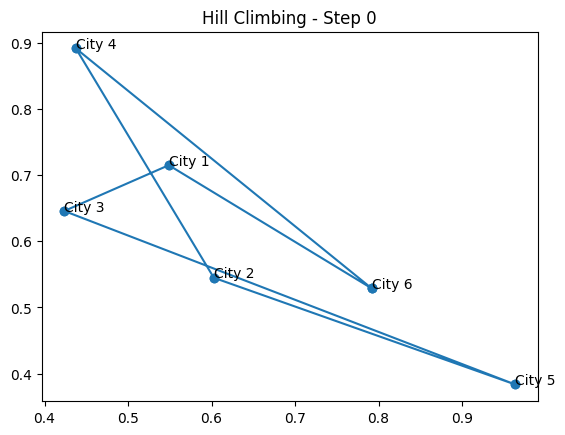

In [44]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

# Run Hill Climbing
best_route, best_cost, history_hc = hill_climbing(cities)

fig, ax = plt.subplots()

def plot_cities_with_labels(ax, cities):
    ax.scatter(cities[:, 0], cities[:, 1])
    for i, (x, y) in enumerate(cities):
        ax.text(x, y, f"City {i+1}", fontsize=10)

def update_hc(frame):
    ax.clear()

    route = history_hc[frame]

    plot_cities_with_labels(ax, cities)

    pts = cities[route + [route[0]]]
    ax.plot(pts[:,0], pts[:,1], marker='o')

    ax.set_title(f"Hill Climbing - Step {frame}")

ani = FuncAnimation(fig, update_hc, frames=len(history_hc), interval=500)
HTML(ani.to_jshtml())

# Genetic Algorithm

In [39]:
POP_SIZE = 20
GENS = 50

def create_individual():
    route = list(range(len(cities)))
    random.shuffle(route)
    return route

def crossover(p1, p2):
    cut = random.randint(1, len(p1)-2)
    child = p1[:cut] + [x for x in p2 if x not in p1[:cut]]
    return child

def mutate(route):
    if random.random() < 0.2:
        i, j = random.sample(range(len(route)), 2)
        route[i], route[j] = route[j], route[i]
    return route

population = [create_individual() for _ in range(POP_SIZE)]

history = []

for _ in range(GENS):
    population = sorted(population, key=total_distance)
    history.append(population[0])

    new_pop = population[:2]

    while len(new_pop) < POP_SIZE:
        p1, p2 = random.sample(population[:10], 2)
        child = crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)

    population = new_pop

**Display**

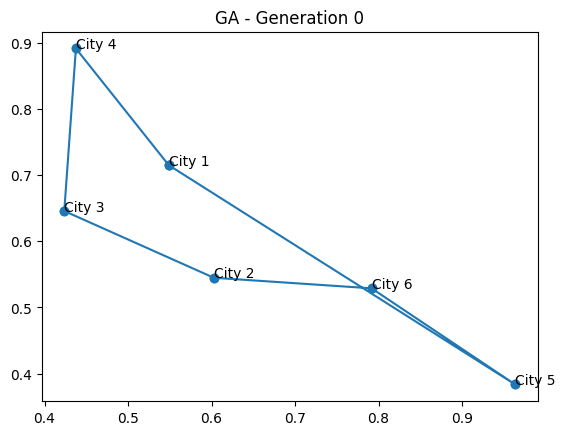

In [40]:
fig, ax = plt.subplots()

def update_ga(frame):
    ax.clear()

    route = history[frame]

    # plot cities + labels
    plot_cities_with_labels(ax, cities)

    pts = cities[route + [route[0]]]
    ax.plot(pts[:,0], pts[:,1], marker='o')

    ax.set_title(f"GA - Generation {frame}")

ani = FuncAnimation(fig, update_ga, frames=len(history), interval=300)
HTML(ani.to_jshtml())

# PSO

In [41]:
NUM_PARTICLES = 15
ITER = 50

def random_route():
    r = list(range(len(cities)))
    random.shuffle(r)
    return r

particles = [random_route() for _ in range(NUM_PARTICLES)]
p_best = particles[:]
g_best = min(particles, key=total_distance)

history_pso = []

def swap(route):
    i, j = random.sample(range(len(route)), 2)
    route[i], route[j] = route[j], route[i]
    return route

for _ in range(ITER):
    for i in range(NUM_PARTICLES):
        new_route = swap(particles[i][:])

        if total_distance(new_route) < total_distance(p_best[i]):
            p_best[i] = new_route

    g_best = min(p_best, key=total_distance)
    history_pso.append(g_best)

**Display**

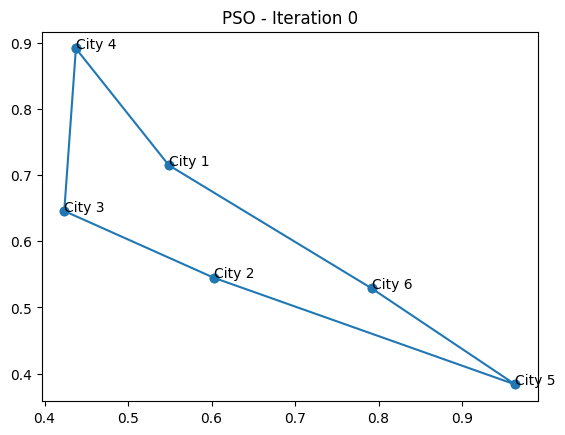

In [42]:
fig, ax = plt.subplots()

def update_pso(frame):
    ax.clear()

    route = history_pso[frame]

    # plot cities + labels
    plot_cities_with_labels(ax, cities)

    pts = cities[route + [route[0]]]
    ax.plot(pts[:,0], pts[:,1], marker='o')

    ax.set_title(f"PSO - Iteration {frame}")

ani = FuncAnimation(fig, update_pso, frames=len(history_pso), interval=300)
HTML(ani.to_jshtml())